# Supervised Learning: Predicting Yield strength (MPa)
## Welding Quality Prediction System

---

**Target Variable:** Yield strength (MPa)  
**Approach:** Supervised Learning with Complete Cases  
**Analysis:** PCA + Multiple Models + XGBoost Optimization

---

## 1. Introduction

### Objective

Develop and evaluate supervised learning models to predict **Yield strength (MPa)** based on:
- Chemical composition of weld material
- Welding process parameters
- Post-weld heat treatment conditions

### Methodology

1. **Data Preparation**
   - Load welding quality dataset
   - Drop rows with missing target values (complete cases only)
   - Handle missing values in features using KNN imputation
   - Feature engineering and encoding

2. **Dimensionality Reduction (PCA)**
   - Apply Principal Component Analysis
   - Analyze variance explained
   - Select optimal number of components (95% threshold)

3. **Model Comparison with PCA**
   - Random Forest Regressor
   - XGBoost
   - Gradient Boosting
   - Ridge Regression
   - Support Vector Regression (SVR)
   - 5-fold cross-validation

4. **XGBoost without PCA**
   - Train on full feature set
   - Hyperparameter tuning with GridSearchCV
   - Feature importance analysis
   - Final model evaluation




## 2. Setup and Data Loading

### 2.1 Import Libraries

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn - Preprocessing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    KFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

# Scikit-learn - Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

# XGBoost
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# Scipy
from scipy import stats

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)
%matplotlib inline

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")
print(f"Random seed: {RANDOM_STATE}")

Libraries imported successfully!
Random seed: 42


### 2.2 Load Dataset

In [ ]:
# Load welding quality dataset
print("Loading welding quality dataset...")
print("="*80)

import os

# Check for preprocessed data first
if os.path.exists('welddb_cleaned.csv'):
    print("Loading preprocessed data from 'welddb_cleaned.csv'")
    df = pd.read_csv('welddb_cleaned.csv')
    print("  -> Preprocessed data loaded")

else:
    print("Preprocessed data not found, loading raw data...")
    print("  -> Loading 'welddb.data'")

    # Load raw data
    df = pd.read_csv('welddb.data', header=None, delim_whitespace=True)

    # Define column names
    column_names = [
        "Carbon concentration (weight%)",
        "Silicon concentration (weight%)",
        "Manganese concentration (weight%)",
        "Sulphur concentration (weight%)",
        "Phosphorus concentration (weight%)",
        "Nickel concentration (weight%)",
        "Chromium concentration (weight%)",
        "Molybdenum concentration (weight%)",
        "Vanadium concentration (weight%)",
        "Copper concentration (weight%)",
        "Cobalt concentration (weight%)",
        "Tungsten concentration (weight%)",
        "Oxygen concentration (ppm by weight)",
        "Titanium concentration (ppm by weight)",
        "Nitrogen concentration (ppm by weight)",
        "Aluminium concentration (ppm by weight)",
        "Boron concentration (ppm by weight)",
        "Niobium concentration (ppm by weight)",
        "Tin concentration (ppm by weight)",
        "Arsenic concentration (ppm by weight)",
        "Antimony concentration (ppm by weight)",
        "Current (A)",
        "Voltage (V)",
        "AC or DC",
        "Electrode polarity (positive or negative)",
        "Heat input (kJmm-1)",
        "Interpass temperature (°C)",
        "Type of weld",
        "Post weld heat treatment temperature (°C)",
        "Post weld heat treatment time (hours)",
        "Yield strength (MPa)",
        "Ultimate tensile strength (MPa)",
        "Elongation (%)",
        "Reduction of Area (%)",
        "Charpy temperature (°C)",
        "Charpy impact toughness (J)",
        "Hardness (kgmm-2)",
        "50% FATT",
        "Primary ferrite in microstructure (%)",
        "Ferrite with second phase (%)",
        "Acicular ferrite (%)",
        "Martensite (%)",
        "Ferrite with carbide aggregate (%)",
        "Weld ID"
    ]

    # Assign column names
    df.columns = column_names

    # Handle missing value indicator
    df.replace("N", np.nan, inplace=True)

    print("  -> Raw data processed")

# Display dataset info
print(f"\nDataset loaded successfully!")
print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80)

# Show first few rows
df.head()

Loading welding quality dataset...
Loading preprocessed data from 'welddb_cleaned.csv'
  -> Preprocessed data loaded

Dataset loaded successfully!
  Shape: 1652 rows × 38 columns
  Memory usage: 0.65 MB



,Carbon concentration (weight%),Silicon concentration (weight%),Manganese concentration (weight%),Sulphur concentration (weight%),Phosphorus concentration (weight%),Nickel concentration (weight%),Chromium concentration (weight%),Molybdenum concentration (weight%),Vanadium concentration (weight%),Copper concentration (weight%),...,Reduction of Area (%),Charpy temperature (°C),Charpy impact toughness (J),Weld ID,Oxygen concentration (weight%),Titanium concentration (weight%),Nitrogen concentration (weight%),Aluminium concentration (weight%),Boron concentration (weight%),Niobium concentration (weight%)
0,0.037,0.30,0.65,0.008,0.012,0.0,0.0,0.0,0.0,0.0,...,80.6,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aaw,0.0,0.0,0.0,0.0,0.0,0.0
1,0.037,0.30,0.65,0.008,0.012,0.0,0.0,0.0,0.0,0.0,...,NaN,-28.0,100.0,Evans-Ni/CMn-1990/1991-0Aawch,0.0,0.0,0.0,0.0,0.0,0.0
2,0.037,0.30,0.65,0.008,0.012,0.0,0.0,0.0,0.0,0.0,...,80.6,-38.0,100.0,Evans-Ni/CMn-1990/1991-0Aht,0.0,0.0,0.0,0.0,0.0,0.0
3,0.037,0.31,1.03,0.007,0.014,0.0,0.0,0.0,0.0,0.0,...,80.6,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw,0.0,0.0,0.0,0.0,0.0,0.0
4,0.037,0.31,1.03,0.007,0.014,0.0,0.0,0.0,0.0,0.0,...,NaN,-48.0,100.0,Evans-Ni/CMn-1990/1991-0Bawch,0.0,0.0,0.0,0.0,0.0,0.0


### 2.3 Target Variable Analysis: Yield strength (MPa)

In [ ]:
# Define target variable
TARGET = "Yield strength (MPa)"

print(f"Target Variable: {TARGET}")
print("="*80)

# Data availability
n_total = len(df)
n_with_target = df[TARGET].notna().sum()
n_missing = df[TARGET].isna().sum()
pct_available = (n_with_target / n_total) * 100

print(f"\nData Availability:")
print(f"  Total samples: {n_total}")
print(f"  With target value: {n_with_target} ({pct_available:.1f}%)")
print(f"  Missing target: {n_missing} ({100-pct_available:.1f}%)")

# Target statistics
print(f"\nTarget Statistics:")
target_data = df[TARGET].dropna()
print(f"  Mean:     {target_data.mean():.2f}")
print(f"  Median:   {target_data.median():.2f}")
print(f"  Std Dev:  {target_data.std():.2f}")
print(f"  Min:      {target_data.min():.2f}")
print(f"  Max:      {target_data.max():.2f}")
print(f"  Range:    {target_data.max() - target_data.min():.2f}")
print(f"  Q1 (25%): {target_data.quantile(0.25):.2f}")
print(f"  Q3 (75%): {target_data.quantile(0.75):.2f}")
print(f"  IQR:      {target_data.quantile(0.75) - target_data.quantile(0.25):.2f}")

print("\n" + "="*80)

Target Variable: Yield strength (MPa)

Data Availability:
  Total samples: 1652
  With target value: 780 (47.2%)
  Missing target: 872 (52.8%)

Target Statistics:
  Mean:     508.56
  Median:   495.00
  Std Dev:  92.87
  Min:      315.00
  Max:      920.00
  Range:    605.00
  Q1 (25%): 443.00
  Q3 (75%): 559.25
  IQR:      116.25



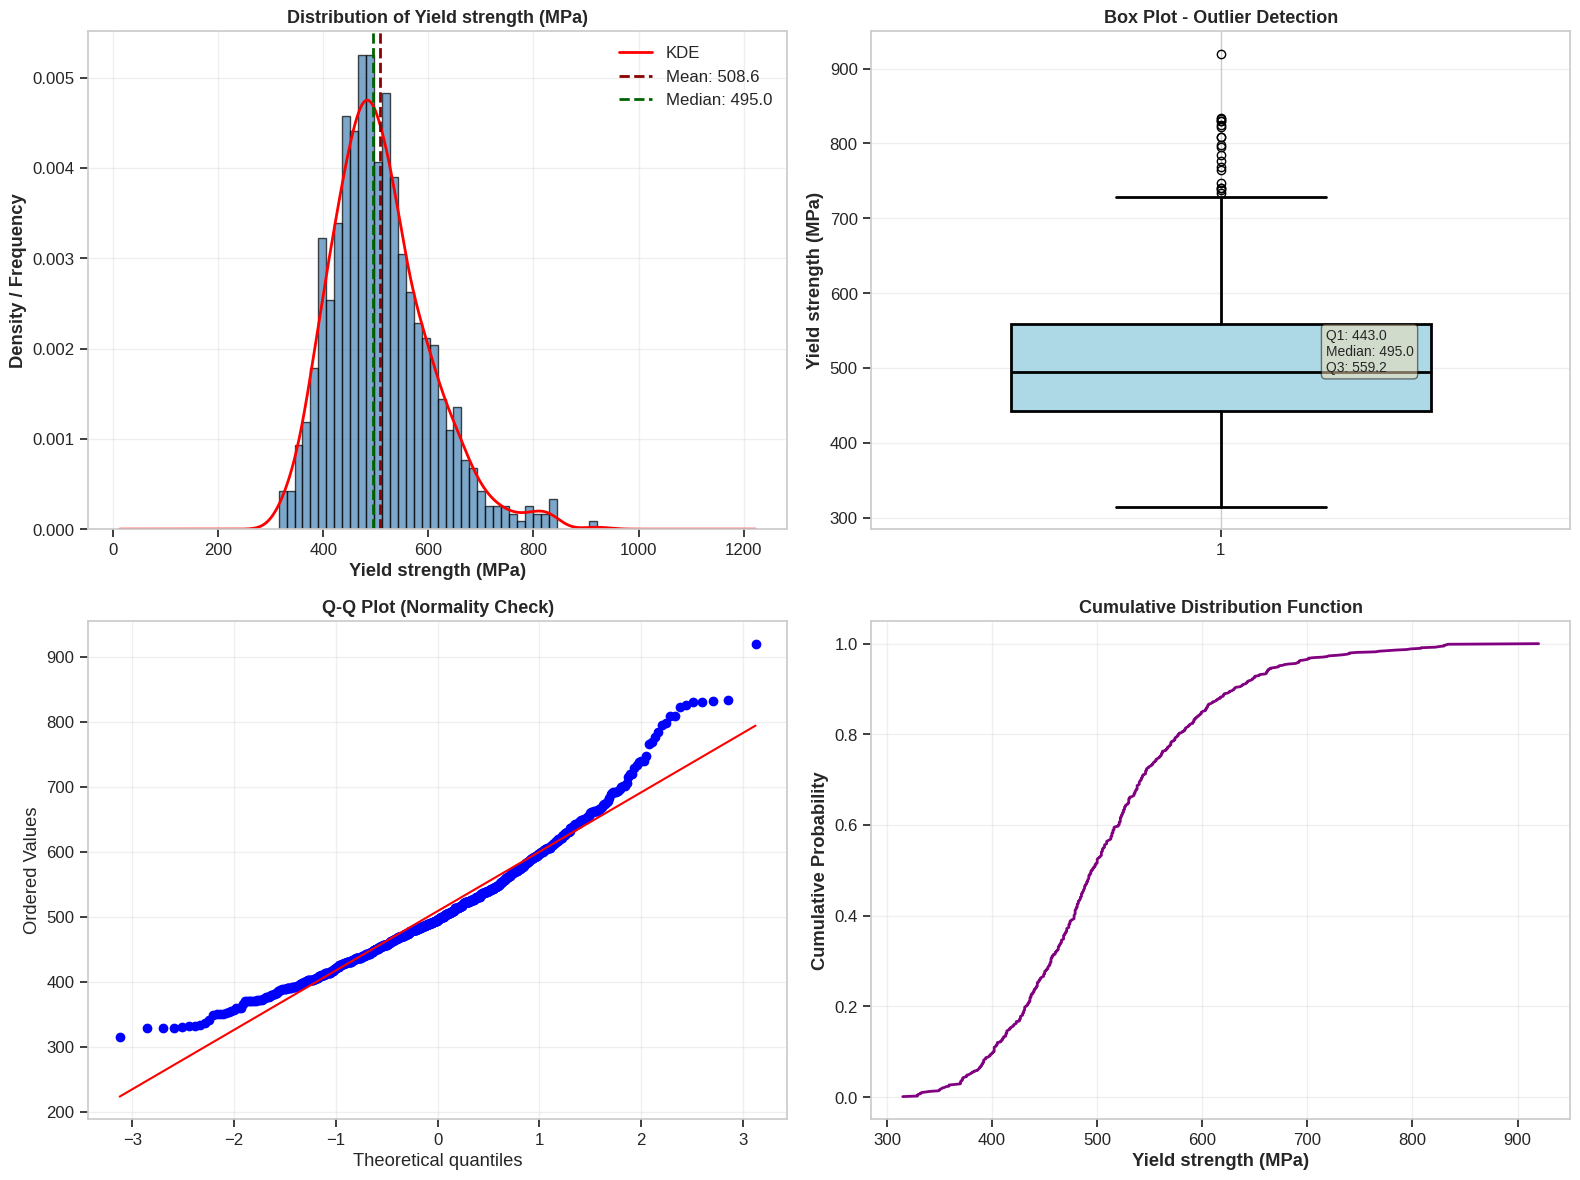


Normality Test (Shapiro-Wilk):
  Statistic: 0.9612
  P-value: 0.0000
  Normally distributed: No (α=0.05)


In [ ]:
# Visualize target distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram with KDE
ax = axes[0, 0]
ax.hist(target_data, bins=40, color='steelblue', edgecolor='black', alpha=0.7, density=True)
target_data.plot(kind='kde', ax=ax, color='red', linewidth=2, label='KDE')
ax.axvline(target_data.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {target_data.mean():.1f}')
ax.axvline(target_data.median(), color='darkgreen', linestyle='--', linewidth=2, label=f'Median: {target_data.median():.1f}')
ax.set_xlabel(TARGET, fontweight='bold')
ax.set_ylabel('Density / Frequency', fontweight='bold')
ax.set_title(f'Distribution of {TARGET}', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

# Box plot
ax = axes[0, 1]
bp = ax.boxplot(target_data, vert=True, patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_edgecolor('black')
bp['boxes'][0].set_linewidth(2)
for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    plt.setp(bp[element], color='black', linewidth=2)
ax.set_ylabel(TARGET, fontweight='bold')
ax.set_title('Box Plot - Outlier Detection', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3, axis='y')

# Add statistics text
stats_text = f"Q1: {target_data.quantile(0.25):.1f}\nMedian: {target_data.median():.1f}\nQ3: {target_data.quantile(0.75):.1f}"
ax.text(1.15, target_data.median(), stats_text, fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Q-Q plot for normality
ax = axes[1, 0]
stats.probplot(target_data, dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Normality Check)', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3)

# Cumulative distribution
ax = axes[1, 1]
sorted_data = np.sort(target_data)
cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
ax.plot(sorted_data, cumulative, linewidth=2, color='purple')
ax.set_xlabel(TARGET, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontweight='bold')
ax.set_title('Cumulative Distribution Function', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Normality test
shapiro_stat, shapiro_p = stats.shapiro(target_data.sample(min(5000, len(target_data)), random_state=RANDOM_STATE))
print(f"\nNormality Test (Shapiro-Wilk):")
print(f"  Statistic: {shapiro_stat:.4f}")
print(f"  P-value: {shapiro_p:.4f}")
print(f"  Normally distributed: {'Yes' if shapiro_p > 0.05 else 'No'} (α=0.05)")

## 3. Data Preparation for Supervised Learning

### 3.1 Select Complete Cases


In [ ]:
# Filter for complete cases (target not missing)
print("Selecting complete cases (rows with target value)...")
print("="*80)
print(f"Before filtering: {len(df)} rows")

df_complete = df.dropna(subset=[TARGET]).copy()

print(f"After filtering:  {len(df_complete)} rows")
print(f"Removed:          {len(df) - len(df_complete)} rows ({(len(df) - len(df_complete))/len(df)*100:.1f}%)")
print(f"Retained:         {len(df_complete)/len(df)*100:.1f}% of data")
print("\n" + "="*80)

Selecting complete cases (rows with target value)...
Before filtering: 1652 rows
After filtering:  780 rows
Removed:          872 rows (52.8%)
Retained:         47.2% of data



### 3.2 Feature Selection

We exclude:
1. **Other target variables** (mechanical properties we're not predicting)
2. **High-missing columns** (>94% missing - unreliable)
3. **ID columns** (not predictive)

In [ ]:
# Define columns to exclude
EXCLUDE_COLS = [
    # Other target variables (mechanical properties)
    "Yield strength (MPa)",
    "Ultimate tensile strength (MPa)",
    "Elongation (%)",
    "Reduction of Area (%)",
    "Charpy temperature (°C)",
    "Charpy impact toughness (J)",
    "50% FATT",
    # Columns with >94% missing values
    "Hardness (kgmm-2)",
    "Primary ferrite in microstructure (%)",
    "Ferrite with second phase (%)",
    "Acicular ferrite (%)",
    "Martensite (%)",
    "Ferrite with carbide aggregate (%)",
    # ID column
    "Weld ID"
]

# Select features
feature_cols = [col for col in df_complete.columns if col not in EXCLUDE_COLS]

X = df_complete[feature_cols].copy()
y = df_complete[TARGET].copy()

print("Feature Selection:")
print("="*80)
print(f"  Total features: {len(feature_cols)}")
print(f"  Dataset shape: X={X.shape}, y={y.shape}")

# Categorize features
chemical_weight = [col for col in feature_cols if 'concentration (weight%)' in col]
chemical_ppm = [col for col in feature_cols if 'ppm by weight' in col]
process_params = [col for col in feature_cols if any(x in col for x in ['Current', 'Voltage', 'Heat', 'temperature', 'time'])]
categorical = [col for col in feature_cols if col in ['Type of weld', 'AC or DC', 'Electrode polarity (positive or negative)']]

print(f"\nFeature Categories:")
print(f"  Chemical (weight%): {len(chemical_weight)}")
print(f"  Chemical (ppm): {len(chemical_ppm)}")
print(f"  Process parameters: {len(process_params)}")
print(f"  Categorical: {len(categorical)}")
print("\n" + "="*80)

Feature Selection:
  Total features: 31
  Dataset shape: X=(780, 31), y=(780,)

Feature Categories:
  Chemical (weight%): 16
  Chemical (ppm): 6
  Process parameters: 6
  Categorical: 3



### 3.3 Handle Categorical Variables

In [ ]:
# Identify categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Categorical Variables:")
print("="*80)
if len(categorical_cols) > 0:
    print(f"Found {len(categorical_cols)} categorical features:")
    for col in categorical_cols:
        print(f"  {col}:")
        print(f"    Unique values: {X[col].nunique()}")
        print(f"    Values: {X[col].unique()[:5].tolist()}")
        print()

    # One-hot encoding
    print("Applying one-hot encoding...")
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    print(f"  Before encoding: {X.shape[1]} features")
    print(f"  After encoding:  {X_encoded.shape[1]} features")
    print(f"  Dummy variables: {X_encoded.shape[1] - X.shape[1]}")

    X = X_encoded
else:
    print("No categorical features found")

print("\n" + "="*80)

Categorical Variables:
Found 1 categorical features:
  Type of weld:
    Unique values: 10
    Values: ['MMA', 'ShMA', 'SA', 'TSA', 'SAA']

Applying one-hot encoding...
  Before encoding: 31 features
  After encoding:  39 features
  Dummy variables: 8



### 3.4 Handle Missing Values in Features

In [ ]:
# Analyze missing values
print("Missing Values Analysis:")
print("="*80)

missing_counts = X.isnull().sum()
missing_features = missing_counts[missing_counts > 0].sort_values(ascending=False)

if len(missing_features) > 0:
    print(f"Features with missing values: {len(missing_features)}")
    print(f"\nTop 15 features with most missing values:")
    for feat, count in missing_features.head(15).items():
        pct = (count / len(X)) * 100
        print(f"  {feat:50s}: {count:4d} ({pct:5.1f}%)")

    print(f"\nTotal missing values: {X.isnull().sum().sum()}")

    # KNN Imputation
    print("\nApplying KNN Imputation...")
    print("  Method: K-Nearest Neighbors (k=5)")
    print("  Reason: Preserves feature relationships better than mean/median")
    print("  Process: Scale → Impute → Inverse scale")

    # Scale for imputation
    scaler_impute = StandardScaler()
    X_scaled_impute = scaler_impute.fit_transform(X)

    # Impute
    imputer = KNNImputer(n_neighbors=5)
    X_imputed = imputer.fit_transform(X_scaled_impute)

    # Inverse scale
    X_imputed = scaler_impute.inverse_transform(X_imputed)
    X = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)

    print(f"  Missing values after imputation: {X.isnull().sum().sum()}")
else:
    print("No missing values in features!")

print("\n" + "="*80)

Missing Values Analysis:
Features with missing values: 6

Top 15 features with most missing values:
  Current (A)                                       :  113 ( 14.5%)
  Voltage (V)                                       :  113 ( 14.5%)
  AC or DC                                          :  109 ( 14.0%)
  Electrode polarity (positive or negative)         :   60 (  7.7%)
  Post weld heat treatment temperature (°C)         :   13 (  1.7%)
  Post weld heat treatment time (hours)             :   13 (  1.7%)

Total missing values: 421

Applying KNN Imputation...
  Method: K-Nearest Neighbors (k=5)
  Reason: Preserves feature relationships better than mean/median
  Process: Scale → Impute → Inverse scale
  Missing values after imputation: 0



### 3.5 Final Dataset Summary

In [ ]:
# Final check
print("Final Dataset Ready:")
print("="*80)
print(f"  Samples:  {len(X)}")
print(f"  Features: {X.shape[1]}")
print(f"  Target:   {TARGET}")
print(f"  Missing:  {X.isnull().sum().sum()} (should be 0)")
print(f"\nData types:")
print(f"  Numeric: {X.select_dtypes(include=[np.number]).shape[1]}")
print(f"  Object:  {X.select_dtypes(include=['object']).shape[1]}")
print("\n" + "="*80)

Final Dataset Ready:
  Samples:  780
  Features: 39
  Target:   Yield strength (MPa)
  Missing:  0 (should be 0)

Data types:
  Numeric: 39
  Object:  0



## 4. Train-Test Split

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

print("Train-Test Split:")
print("="*80)
print(f"  Training samples:   {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test samples:       {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Split ratio:        80-20")
print(f"  Random state:       {RANDOM_STATE}")
print(f"\nTarget distribution:")
print(f"  Train - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"  Test  - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")
print("\n" + "="*80)

Train-Test Split:
  Training samples:   624 (80.0%)
  Test samples:       156 (20.0%)
  Split ratio:        80-20
  Random state:       42

Target distribution:
  Train - Mean: 507.27, Std: 92.26
  Test  - Mean: 513.69, Std: 95.37



## 5. Principal Component Analysis (PCA)



The welding quality dataset presents a high-dimensional feature space with 36 variables spanning chemical composition chemical composition, welding parameters, and process encodings, our feature space is high-dimensional and likely contains correlated variables. This multicollinearity can lead to overfitting and reduced model generalization, particularly when working with limited labeled samples.

PCA reduces dimensionality by transforming features into uncorrelated principal components while retaining 95% of the variance. This simplifies the feature space for supervised models, reduces computational cost, and allows us to compare performance between reduced and full feature sets to determine the optimal modeling approach.

In [ ]:
# Standardize features (required for PCA)
print("Step 1: Standardizing Features")
print("="*80)
print("  Why: PCA is sensitive to feature scales")
print("  Method: StandardScaler (mean=0, std=1)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"  Features scaled: {X_train_scaled.shape[1]}")
print("\n" + "="*80)

# Apply PCA
print("\nStep 2: Applying PCA")
print("="*80)

pca = PCA(random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Variance explained
variance_explained = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_explained)

# Find components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"  Total components possible: {len(variance_explained)}")
print(f"  Components for 95% variance: {n_components_95}")
print(f"  Dimensionality reduction: {X_train.shape[1]} → {n_components_95}")
print(f"  Reduction: {(1 - n_components_95/X_train.shape[1])*100:.1f}%")
print(f"\nVariance explained by first components:")
print(f"  PC1:       {variance_explained[0]*100:.2f}%")
print(f"  PC1+PC2:   {cumulative_variance[1]*100:.2f}%")
print(f"  PC1-PC3:   {cumulative_variance[2]*100:.2f}%")
print(f"  First {n_components_95}:  {cumulative_variance[n_components_95-1]*100:.2f}%")
print("\n" + "="*80)

Step 1: Standardizing Features
  Why: PCA is sensitive to feature scales
  Method: StandardScaler (mean=0, std=1)
  Features scaled: 39


Step 2: Applying PCA
  Total components possible: 39
  Components for 95% variance: 24
  Dimensionality reduction: 39 → 24
  Reduction: 38.5%

Variance explained by first components:
  PC1:       14.78%
  PC1+PC2:   27.38%
  PC1-PC3:   34.83%
  First 24:  96.01%



### 5.1 PCA Visualizations

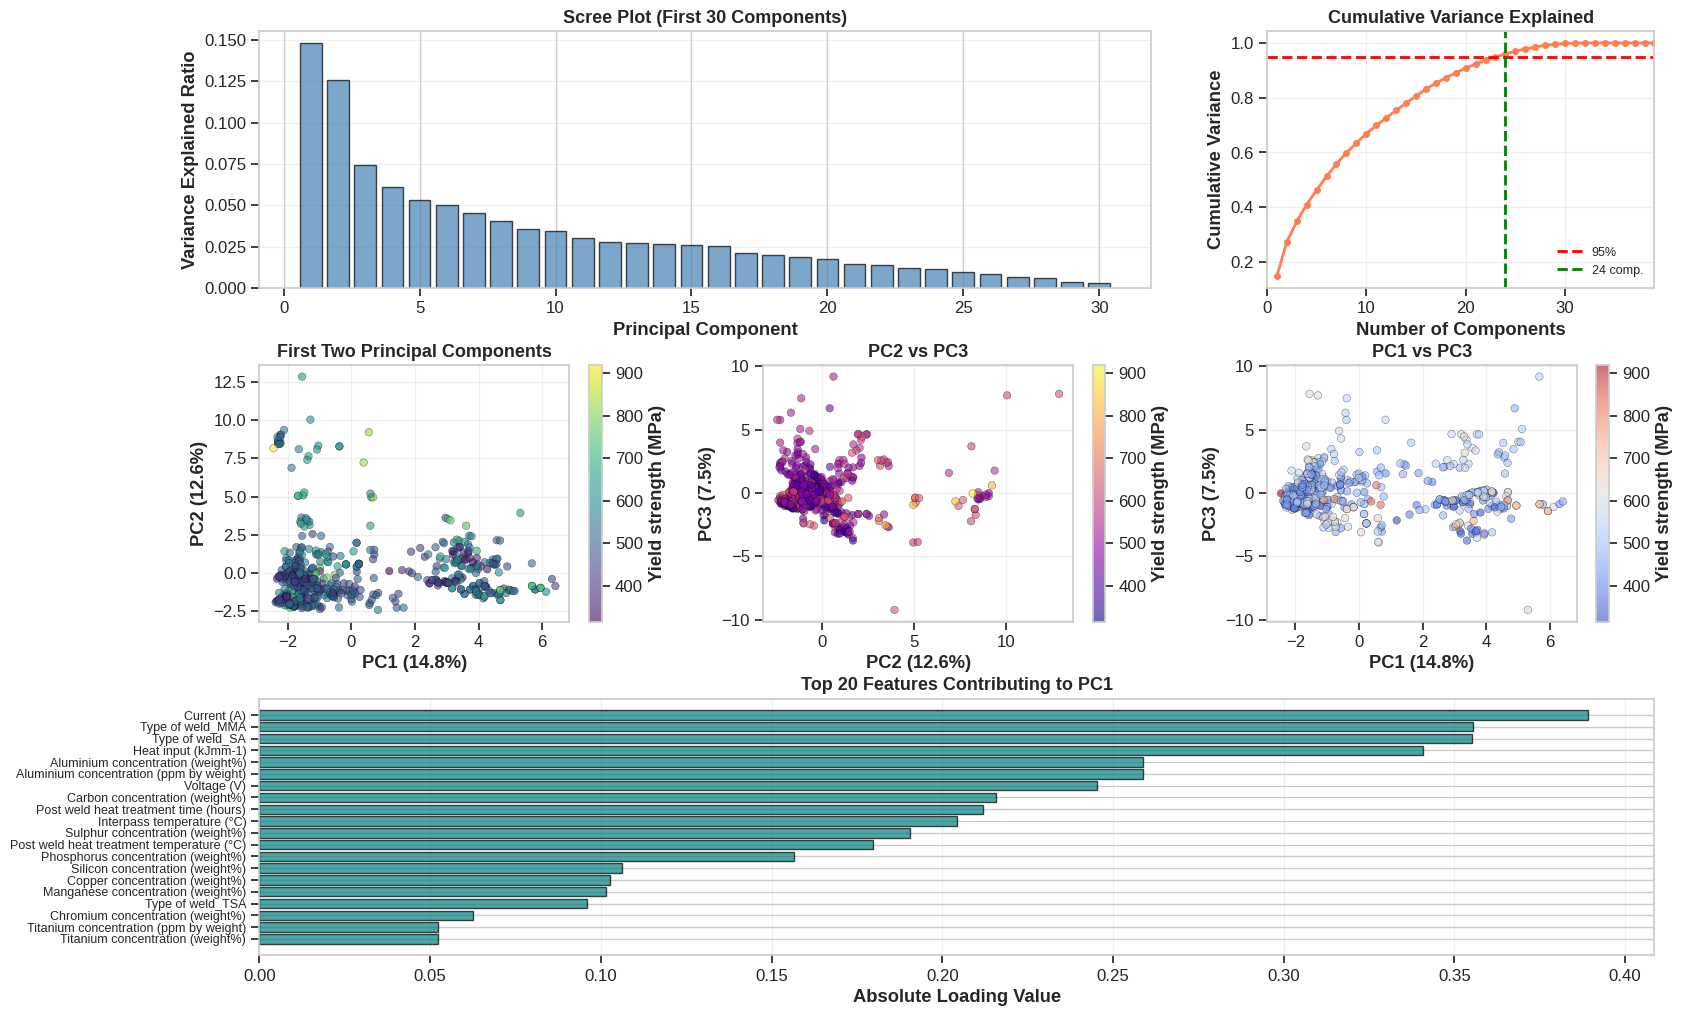

Key Insight: Using 24 components captures 95% of variance
  Original features: 39
  PCA components: 24
  Information retained: 95%
  Complexity reduced: 38.5%


In [ ]:
# Create comprehensive PCA visualizations
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Scree Plot
ax1 = fig.add_subplot(gs[0, :2])
n_show = min(30, len(variance_explained))
ax1.bar(range(1, n_show+1), variance_explained[:n_show],
        alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('Principal Component', fontweight='bold')
ax1.set_ylabel('Variance Explained Ratio', fontweight='bold')
ax1.set_title(f'Scree Plot (First {n_show} Components)', fontweight='bold', fontsize=13)
ax1.grid(alpha=0.3, axis='y')

# 2. Cumulative Variance
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance,
        'o-', linewidth=2, markersize=4, color='coral')
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95%')
ax2.axvline(x=n_components_95, color='green', linestyle='--', linewidth=2,
           label=f'{n_components_95} comp.')
ax2.set_xlabel('Number of Components', fontweight='bold')
ax2.set_ylabel('Cumulative Variance', fontweight='bold')
ax2.set_title('Cumulative Variance Explained', fontweight='bold', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_xlim([0, min(50, len(cumulative_variance))])

# 3. PC1 vs PC2 colored by target
ax3 = fig.add_subplot(gs[1, 0])
scatter = ax3.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                     c=y_train, cmap='viridis', alpha=0.6, s=30, edgecolors='k', linewidth=0.3)
ax3.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)', fontweight='bold')
ax3.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}%)', fontweight='bold')
ax3.set_title('First Two Principal Components', fontweight='bold', fontsize=13)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label(TARGET, fontweight='bold')
ax3.grid(alpha=0.3)

# 4. PC2 vs PC3
ax4 = fig.add_subplot(gs[1, 1])
scatter2 = ax4.scatter(X_train_pca[:, 1], X_train_pca[:, 2],
                      c=y_train, cmap='plasma', alpha=0.6, s=30, edgecolors='k', linewidth=0.3)
ax4.set_xlabel(f'PC2 ({variance_explained[1]*100:.1f}%)', fontweight='bold')
ax4.set_ylabel(f'PC3 ({variance_explained[2]*100:.1f}%)', fontweight='bold')
ax4.set_title('PC2 vs PC3', fontweight='bold', fontsize=13)
cbar2 = plt.colorbar(scatter2, ax=ax4)
cbar2.set_label(TARGET, fontweight='bold')
ax4.grid(alpha=0.3)

# 5. PC1 vs PC3
ax5 = fig.add_subplot(gs[1, 2])
scatter3 = ax5.scatter(X_train_pca[:, 0], X_train_pca[:, 2],
                      c=y_train, cmap='coolwarm', alpha=0.6, s=30, edgecolors='k', linewidth=0.3)
ax5.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)', fontweight='bold')
ax5.set_ylabel(f'PC3 ({variance_explained[2]*100:.1f}%)', fontweight='bold')
ax5.set_title('PC1 vs PC3', fontweight='bold', fontsize=13)
cbar3 = plt.colorbar(scatter3, ax=ax5)
cbar3.set_label(TARGET, fontweight='bold')
ax5.grid(alpha=0.3)

# 6. Feature Loadings on PC1
ax6 = fig.add_subplot(gs[2, :])
n_features_show = min(20, len(X.columns))
feature_importance_pc1 = np.abs(pca.components_[0])
top_features_idx = np.argsort(feature_importance_pc1)[-n_features_show:]
top_features = [X.columns[i] for i in top_features_idx]
top_loadings = feature_importance_pc1[top_features_idx]

ax6.barh(range(n_features_show), top_loadings, color='teal', edgecolor='black', alpha=0.7)
ax6.set_yticks(range(n_features_show))
ax6.set_yticklabels(top_features, fontsize=9)
ax6.set_xlabel('Absolute Loading Value', fontweight='bold')
ax6.set_title(f'Top {n_features_show} Features Contributing to PC1', fontweight='bold', fontsize=13)
ax6.grid(alpha=0.3, axis='x')

plt.show()

print(f"Key Insight: Using {n_components_95} components captures 95% of variance")
print(f"  Original features: {X.shape[1]}")
print(f"  PCA components: {n_components_95}")
print(f"  Information retained: 95%")
print(f"  Complexity reduced: {(1 - n_components_95/X.shape[1])*100:.1f}%")

Needing this many components (53% of original features) indicates that variance is distributed across many dimensions rather than concentrated in a few. That is likely caused by the classes features. The binary variables are mutually exclusive and cannot be meaningfully compressed through linear combinations—each represents distinct information that PCA cannot reduce.

This explains why PCA models underperform: tree-based models like XGBoost handle categorical features and non-linear interactions naturally without requiring dimensionality reduction. For this mixed-variable problem, the full feature set preserves critical information that gets diluted in PCA transformation.

## 6. Model Comparison with PCA Features

We'll compare multiple regression algorithms using PCA-transformed features.

### Models to Evaluate

1. **Random Forest** - Ensemble of decision trees, robust to outliers
2. **XGBoost** - Gradient boosting, state-of-the-art performance
3. **Gradient Boosting** - Sklearn's boosting implementation
4. **Ridge Regression** - Linear model with L2 regularization
5. **Support Vector Regression** - Kernel-based method

### Evaluation Strategy

- **Cross-Validation:** 5-fold CV on training data
- **Metrics:** R², RMSE, MAE
- **Selection:** Best model based on R² score

In [ ]:
# Select PCA components
n_components_final = n_components_95
X_train_pca_reduced = X_train_pca[:, :n_components_final]
X_test_pca_reduced = X_test_pca[:, :n_components_final]

print(f"Using {n_components_final} PCA components for modeling")
print("="*80)

# Define models with reasonable hyperparameters
models_pca = {
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),
    'Ridge': Ridge(
        alpha=1.0,
        random_state=RANDOM_STATE
    ),
    'SVR': SVR(
        kernel='rbf',
        C=100,
        gamma='scale',
        epsilon=0.1
    )
}

print(f"Models defined: {len(models_pca)}")
print("\nStarting 5-fold cross-validation...")
print("="*80)

# Cross-validation
cv_results_pca = {}
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for i, (name, model) in enumerate(models_pca.items(), 1):
    print(f"\n[{i}/{len(models_pca)}] {name}:")

    # Compute CV scores
    cv_r2 = cross_val_score(model, X_train_pca_reduced, y_train,
                           cv=kf, scoring='r2', n_jobs=-1)
    cv_rmse = -cross_val_score(model, X_train_pca_reduced, y_train,
                               cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_mae = -cross_val_score(model, X_train_pca_reduced, y_train,
                              cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

    cv_results_pca[name] = {
        'r2_mean': cv_r2.mean(),
        'r2_std': cv_r2.std(),
        'rmse_mean': cv_rmse.mean(),
        'rmse_std': cv_rmse.std(),
        'mae_mean': cv_mae.mean(),
        'mae_std': cv_mae.std()
    }

    print(f"  R2:   {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")
    print(f"  RMSE: {cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}")
    print(f"  MAE:  {cv_mae.mean():.4f} +/- {cv_mae.std():.4f}")

print("\n" + "="*80)
print("Cross-validation complete!")

Using 24 PCA components for modeling
Models defined: 5

Starting 5-fold cross-validation...

[1/5] Random Forest:
  R2:   0.5977 +/- 0.0423
  RMSE: 58.2904 +/- 4.2161
  MAE:  40.6743 +/- 2.5614

[2/5] XGBoost:
  R2:   0.6371 +/- 0.0916
  RMSE: 54.9721 +/- 6.6124
  MAE:  37.2414 +/- 4.1405

[3/5] Gradient Boosting:
  R2:   0.6577 +/- 0.0379
  RMSE: 53.7568 +/- 3.9522
  MAE:  37.2425 +/- 2.2494

[4/5] Ridge:
  R2:   0.3686 +/- 0.0969
  RMSE: 72.7676 +/- 5.5575
  MAE:  54.1162 +/- 3.8095

[5/5] SVR:
  R2:   0.6091 +/- 0.0823
  RMSE: 57.2568 +/- 6.6966
  MAE:  36.9708 +/- 3.4724

Cross-validation complete!


### 6.1 PCA Model Comparison Results

Model Performance Comparison (with PCA):
                    r2_mean    r2_std  rmse_mean  rmse_std   mae_mean   mae_std
Gradient Boosting  0.657702  0.037859  53.756775  3.952232  37.242487  2.249412
XGBoost            0.637117  0.091649  54.972121  6.612369  37.241441  4.140461
SVR                0.609109  0.082272  57.256833  6.696612  36.970792  3.472362
Random Forest      0.597705  0.042296  58.290354  4.216057  40.674257  2.561355
Ridge              0.368641  0.096908  72.767577  5.557516  54.116208  3.809485

Best Model: Gradient Boosting
  R2:   0.6577
  RMSE: 53.7568
  MAE:  37.2425


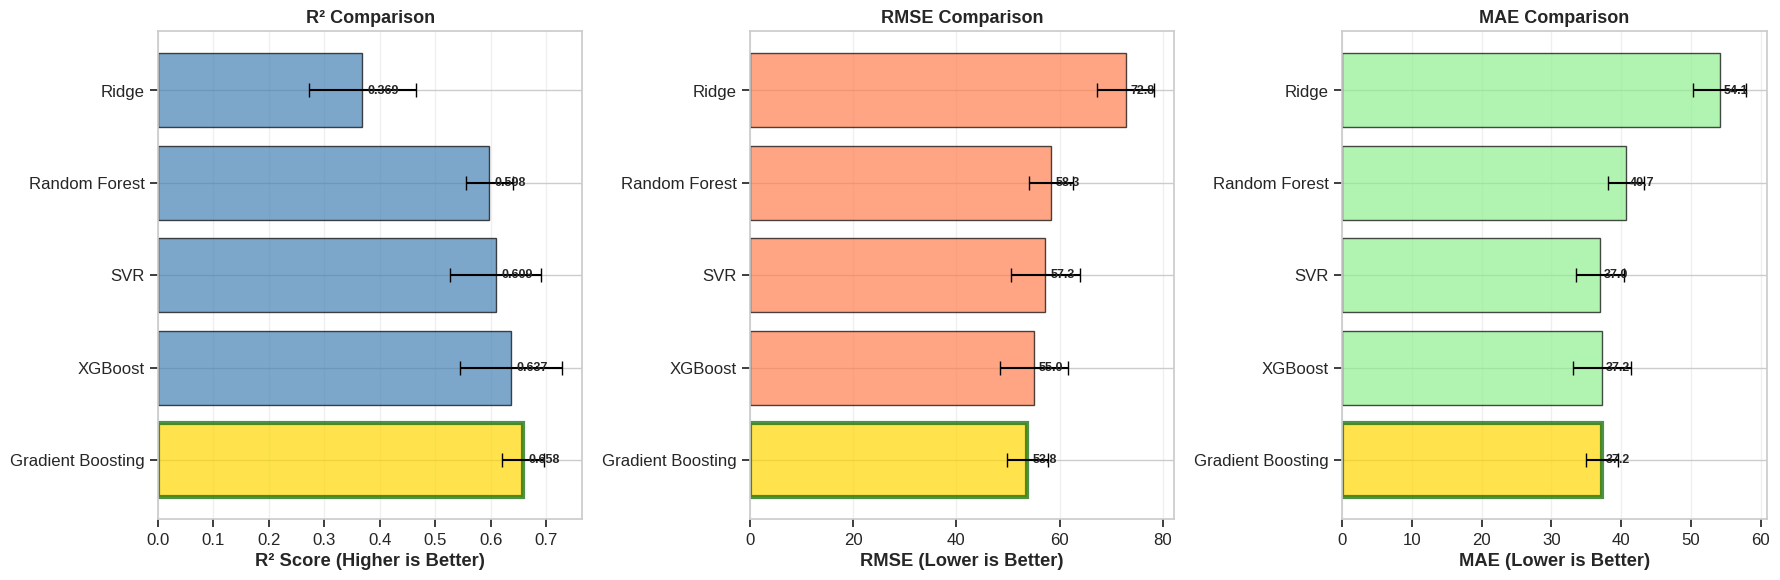

In [ ]:
# Create comparison dataframe
comparison_pca_df = pd.DataFrame(cv_results_pca).T
comparison_pca_df = comparison_pca_df.sort_values('r2_mean', ascending=False)

print("Model Performance Comparison (with PCA):")
print("="*80)
print(comparison_pca_df.to_string())

best_model_pca = comparison_pca_df.index[0]
print(f"\nBest Model: {best_model_pca}")
print(f"  R2:   {comparison_pca_df.loc[best_model_pca, 'r2_mean']:.4f}")
print(f"  RMSE: {comparison_pca_df.loc[best_model_pca, 'rmse_mean']:.4f}")
print(f"  MAE:  {comparison_pca_df.loc[best_model_pca, 'mae_mean']:.4f}")
print("="*80)

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_list = comparison_pca_df.index.tolist()

# R2 comparison
ax = axes[0]
r2_means = comparison_pca_df['r2_mean'].values
r2_stds = comparison_pca_df['r2_std'].values
bars = ax.barh(range(len(models_list)), r2_means, xerr=r2_stds,
              color='steelblue', edgecolor='black', alpha=0.7, capsize=5)
bars[0].set_color('gold')
bars[0].set_edgecolor('darkgreen')
bars[0].set_linewidth(3)
ax.set_yticks(range(len(models_list)))
ax.set_yticklabels(models_list)
ax.set_xlabel('R² Score (Higher is Better)', fontweight='bold')
ax.set_title('R² Comparison', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3, axis='x')
for i, (m, s) in enumerate(zip(r2_means, r2_stds)):
    ax.text(m + 0.01, i, f'{m:.3f}', va='center', fontsize=9, fontweight='bold')

# RMSE comparison
ax = axes[1]
rmse_means = comparison_pca_df['rmse_mean'].values
rmse_stds = comparison_pca_df['rmse_std'].values
bars = ax.barh(range(len(models_list)), rmse_means, xerr=rmse_stds,
              color='coral', edgecolor='black', alpha=0.7, capsize=5)
bars[0].set_color('gold')
bars[0].set_edgecolor('darkgreen')
bars[0].set_linewidth(3)
ax.set_yticks(range(len(models_list)))
ax.set_yticklabels(models_list)
ax.set_xlabel('RMSE (Lower is Better)', fontweight='bold')
ax.set_title('RMSE Comparison', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3, axis='x')
for i, (m, s) in enumerate(zip(rmse_means, rmse_stds)):
    ax.text(m + 1, i, f'{m:.1f}', va='center', fontsize=9, fontweight='bold')

# MAE comparison
ax = axes[2]
mae_means = comparison_pca_df['mae_mean'].values
mae_stds = comparison_pca_df['mae_std'].values
bars = ax.barh(range(len(models_list)), mae_means, xerr=mae_stds,
              color='lightgreen', edgecolor='black', alpha=0.7, capsize=5)
bars[0].set_color('gold')
bars[0].set_edgecolor('darkgreen')
bars[0].set_linewidth(3)
ax.set_yticks(range(len(models_list)))
ax.set_yticklabels(models_list)
ax.set_xlabel('MAE (Lower is Better)', fontweight='bold')
ax.set_title('MAE Comparison', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3, axis='x')
for i, (m, s) in enumerate(zip(mae_means, mae_stds)):
    ax.text(m + 0.5, i, f'{m:.1f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. XGBoost without PCA (Full Feature Set)

Now we train XGBoost using all original features (without dimensionality reduction).

### 7.1 XGBoost Baseline (Default Parameters)

In [ ]:
# Train XGBoost with default parameters on scaled features
print("Training XGBoost with Full Feature Set")
print("="*80)
print(f"Features: {X_train_scaled.shape[1]}")
print(f"Training samples: {X_train_scaled.shape[0]}")

xgb_baseline = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Cross-validation
print("\nPerforming 5-fold cross-validation...")
cv_r2_baseline = cross_val_score(xgb_baseline, X_train_scaled, y_train,
                                 cv=5, scoring='r2', n_jobs=-1)
cv_rmse_baseline = -cross_val_score(xgb_baseline, X_train_scaled, y_train,
                                    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_mae_baseline = -cross_val_score(xgb_baseline, X_train_scaled, y_train,
                                   cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

print("\nCross-Validation Results (Baseline XGBoost):")
print(f"  R2:   {cv_r2_baseline.mean():.4f} +/- {cv_r2_baseline.std():.4f}")
print(f"  RMSE: {cv_rmse_baseline.mean():.4f} +/- {cv_rmse_baseline.std():.4f}")
print(f"  MAE:  {cv_mae_baseline.mean():.4f} +/- {cv_mae_baseline.std():.4f}")

# Train on full training set
xgb_baseline.fit(X_train_scaled, y_train)

# Evaluate on test set
y_pred_baseline = xgb_baseline.predict(X_test_scaled)
test_r2_baseline = r2_score(y_test, y_pred_baseline)
test_rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
test_mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

print("\nTest Set Performance:")
print(f"  R2:   {test_r2_baseline:.4f}")
print(f"  RMSE: {test_rmse_baseline:.4f}")
print(f"  MAE:  {test_mae_baseline:.4f}")
print("\n" + "="*80)

Training XGBoost with Full Feature Set
Features: 39
Training samples: 624

Performing 5-fold cross-validation...

Cross-Validation Results (Baseline XGBoost):
  R2:   0.7557 +/- 0.1048
  RMSE: 43.3195 +/- 4.0419
  MAE:  27.4744 +/- 2.1920

Test Set Performance:
  R2:   0.8585
  RMSE: 35.7645
  MAE:  25.8796



### 7.2 Hyperparameter Tuning

In [ ]:
# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

n_combinations = np.prod([len(v) for v in param_grid.values()])

print("Hyperparameter Tuning with GridSearchCV")
print("="*80)
print(f"Parameter grid:")
for param, values in param_grid.items():
    print(f"  {param:20s}: {values}")
print(f"\nTotal combinations: {n_combinations}")
print(f"CV folds: 5")
print(f"Total fits: {n_combinations * 5}")
print("\nThis may take several minutes...")
print("="*80)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit
import time
start_time = time.time()
grid_search.fit(X_train_scaled, y_train)
elapsed = time.time() - start_time

print(f"\nGrid search completed in {elapsed/60:.1f} minutes")
print("="*80)

# Best parameters
print("\nBest Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:20s}: {value}")

print(f"\nBest CV R2 Score: {grid_search.best_score_:.4f}")
print("="*80)

# Get tuned model
xgb_tuned = grid_search.best_estimator_

# Evaluate on test set
y_pred_tuned = xgb_tuned.predict(X_test_scaled)
test_r2_tuned = r2_score(y_test, y_pred_tuned)
test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
test_mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print("\nTuned Model - Test Set Performance:")
print(f"  R2:   {test_r2_tuned:.4f}")
print(f"  RMSE: {test_rmse_tuned:.4f}")
print(f"  MAE:  {test_mae_tuned:.4f}")

print(f"\nImprovement over baseline:")
print(f"  R2:   {(test_r2_tuned - test_r2_baseline):+.4f} ({(test_r2_tuned - test_r2_baseline)/abs(test_r2_baseline)*100:+.2f}%)")
print(f"  RMSE: {(test_rmse_baseline - test_rmse_tuned):+.4f} ({(test_rmse_baseline - test_rmse_tuned)/test_rmse_baseline*100:+.2f}%)")
print(f"  MAE:  {(test_mae_baseline - test_mae_tuned):+.4f} ({(test_mae_baseline - test_mae_tuned)/test_mae_baseline*100:+.2f}%)")
print("="*80)

Hyperparameter Tuning with GridSearchCV
Parameter grid:
  n_estimators        : [100, 200, 300]
  max_depth           : [3, 5, 7, 9]
  learning_rate       : [0.01, 0.05, 0.1]
  min_child_weight    : [1, 3, 5]
  subsample           : [0.8, 0.9, 1.0]
  colsample_bytree    : [0.8, 0.9, 1.0]

Total combinations: 972
CV folds: 5
Total fits: 4860

This may take several minutes...
Fitting 5 folds for each of 972 candidates, totalling 4860 fits

Grid search completed in 29.7 minutes

Best Hyperparameters:
  colsample_bytree    : 1.0
  learning_rate       : 0.1
  max_depth           : 3
  min_child_weight    : 3
  n_estimators        : 300
  subsample           : 0.9

Best CV R2 Score: 0.8000

Tuned Model - Test Set Performance:
  R2:   0.8597
  RMSE: 35.6074
  MAE:  25.4890

Improvement over baseline:
  R2:   +0.0012 (+0.14%)
  RMSE: +0.1572 (+0.44%)
  MAE:  +0.3905 (+1.51%)


### 7.3 Feature Importance Analysis

Feature Importance Analysis

Top 20 Most Important Features:
                                  Feature  Importance
       Molybdenum concentration (weight%)    0.222509
         Chromium concentration (weight%)    0.097874
        Manganese concentration (weight%)    0.085510
         Vanadium concentration (weight%)    0.078796
           Nickel concentration (weight%)    0.075866
    Post weld heat treatment time (hours)    0.069355
    Niobium concentration (ppm by weight)    0.048086
                              Voltage (V)    0.035011
                      Heat input (kJmm-1)    0.027499
                              Current (A)    0.027280
                       Type of weld_NGSAW    0.025740
       Phosphorus concentration (weight%)    0.024636
                          Type of weld_SA    0.023126
Post weld heat treatment temperature (°C)    0.020734
          Silicon concentration (weight%)    0.018705
     Oxygen concentration (ppm by weight)    0.018166
           Copper con

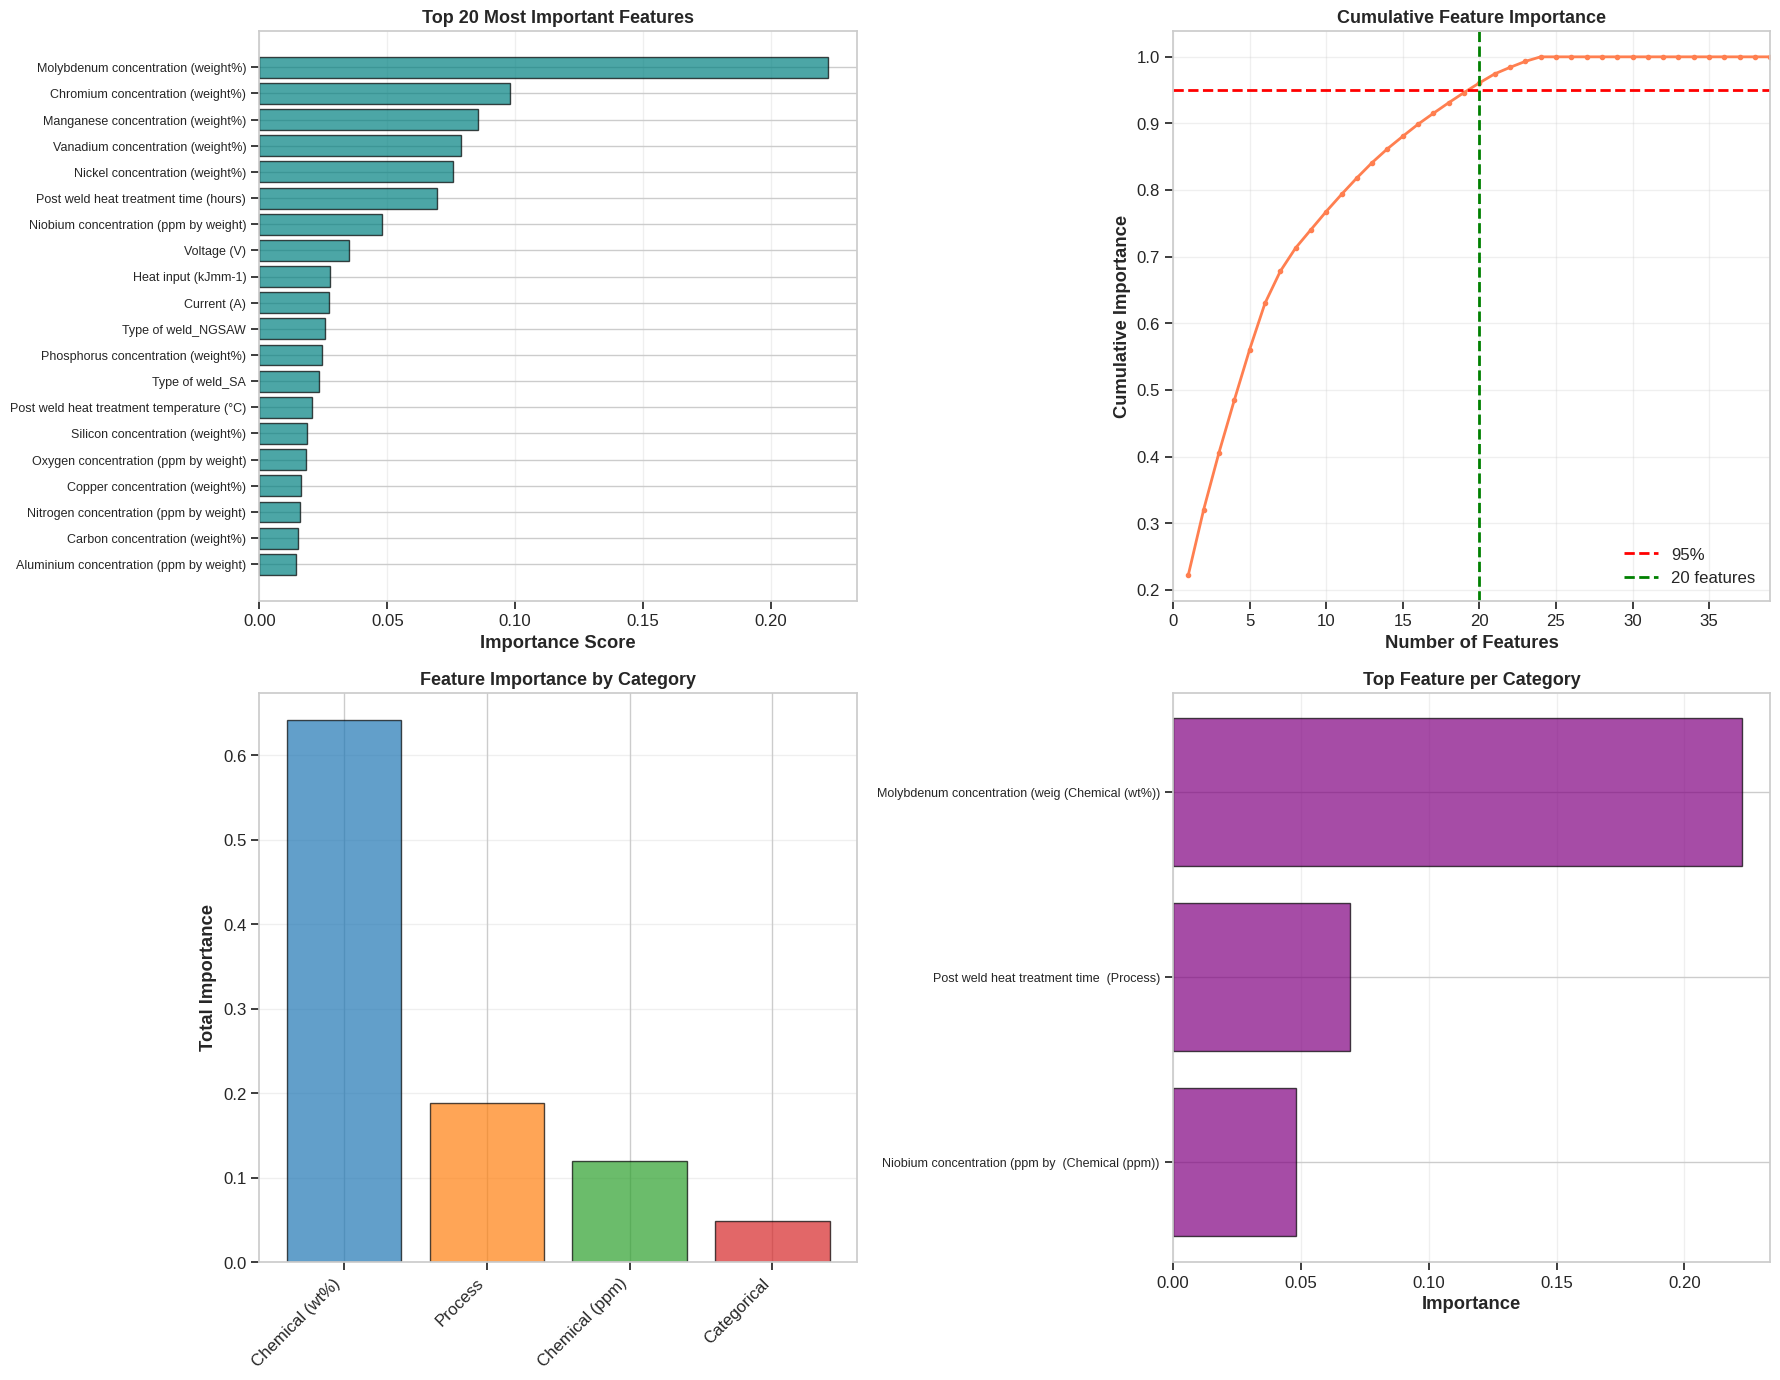

In [ ]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance Analysis")
print("="*80)
print("\nTop 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

# Calculate cumulative importance
feature_importance['Cumulative'] = feature_importance['Importance'].cumsum()
n_features_95 = (feature_importance['Cumulative'] <= 0.95).sum() + 1

print(f"\nFeatures accounting for 95% of importance: {n_features_95}/{len(X.columns)}")
print(f"Reduction possible: {(1 - n_features_95/len(X.columns))*100:.1f}%")
print("="*80)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Top 20 features
ax = axes[0, 0]
top_20 = feature_importance.head(20)
ax.barh(range(len(top_20)), top_20['Importance'],
        color='teal', edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['Feature'], fontsize=9)
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Top 20 Most Important Features', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3, axis='x')
ax.invert_yaxis()

# Cumulative importance
ax = axes[0, 1]
ax.plot(range(1, len(feature_importance)+1),
        feature_importance['Cumulative'].values,
        'o-', linewidth=2, markersize=3, color='coral')
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95%')
ax.axvline(x=n_features_95, color='green', linestyle='--', linewidth=2,
          label=f'{n_features_95} features')
ax.set_xlabel('Number of Features', fontweight='bold')
ax.set_ylabel('Cumulative Importance', fontweight='bold')
ax.set_title('Cumulative Feature Importance', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim([0, min(100, len(feature_importance))])

# Feature importance by category
ax = axes[1, 0]
feature_importance['Category'] = 'Other'
for idx, row in feature_importance.iterrows():
    feat = row['Feature']
    if 'concentration (weight%)' in feat:
        feature_importance.at[idx, 'Category'] = 'Chemical (wt%)'
    elif 'ppm by weight' in feat:
        feature_importance.at[idx, 'Category'] = 'Chemical (ppm)'
    elif any(x in feat for x in ['Current', 'Voltage', 'Heat', 'temperature', 'time']):
        feature_importance.at[idx, 'Category'] = 'Process'
    elif 'Type of weld' in feat or 'AC or DC' in feat or 'polarity' in feat:
        feature_importance.at[idx, 'Category'] = 'Categorical'

category_importance = feature_importance.groupby('Category')['Importance'].sum().sort_values(ascending=False)
colors_cat = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax.bar(range(len(category_importance)), category_importance.values,
       color=colors_cat[:len(category_importance)], edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(category_importance)))
ax.set_xticklabels(category_importance.index, rotation=45, ha='right')
ax.set_ylabel('Total Importance', fontweight='bold')
ax.set_title('Feature Importance by Category', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3, axis='y')

# Top features in each category (top 5)
ax = axes[1, 1]
categories = feature_importance['Category'].unique()[:3]
top_per_category = []
for cat in categories:
    top_feat = feature_importance[feature_importance['Category'] == cat].head(1)
    if not top_feat.empty:
        top_per_category.append({
            'Feature': top_feat.iloc[0]['Feature'][:30],
            'Importance': top_feat.iloc[0]['Importance'],
            'Category': cat
        })

if top_per_category:
    top_df = pd.DataFrame(top_per_category)
    bars = ax.barh(range(len(top_df)), top_df['Importance'],
                   color='purple', edgecolor='black', alpha=0.7)
    ax.set_yticks(range(len(top_df)))
    ax.set_yticklabels([f"{row['Feature']} ({row['Category']})"
                        for _, row in top_df.iterrows()], fontsize=9)
    ax.set_xlabel('Importance', fontweight='bold')
    ax.set_title('Top Feature per Category', fontweight='bold', fontsize=13)
    ax.grid(alpha=0.3, axis='x')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 7.4 Prediction Visualization

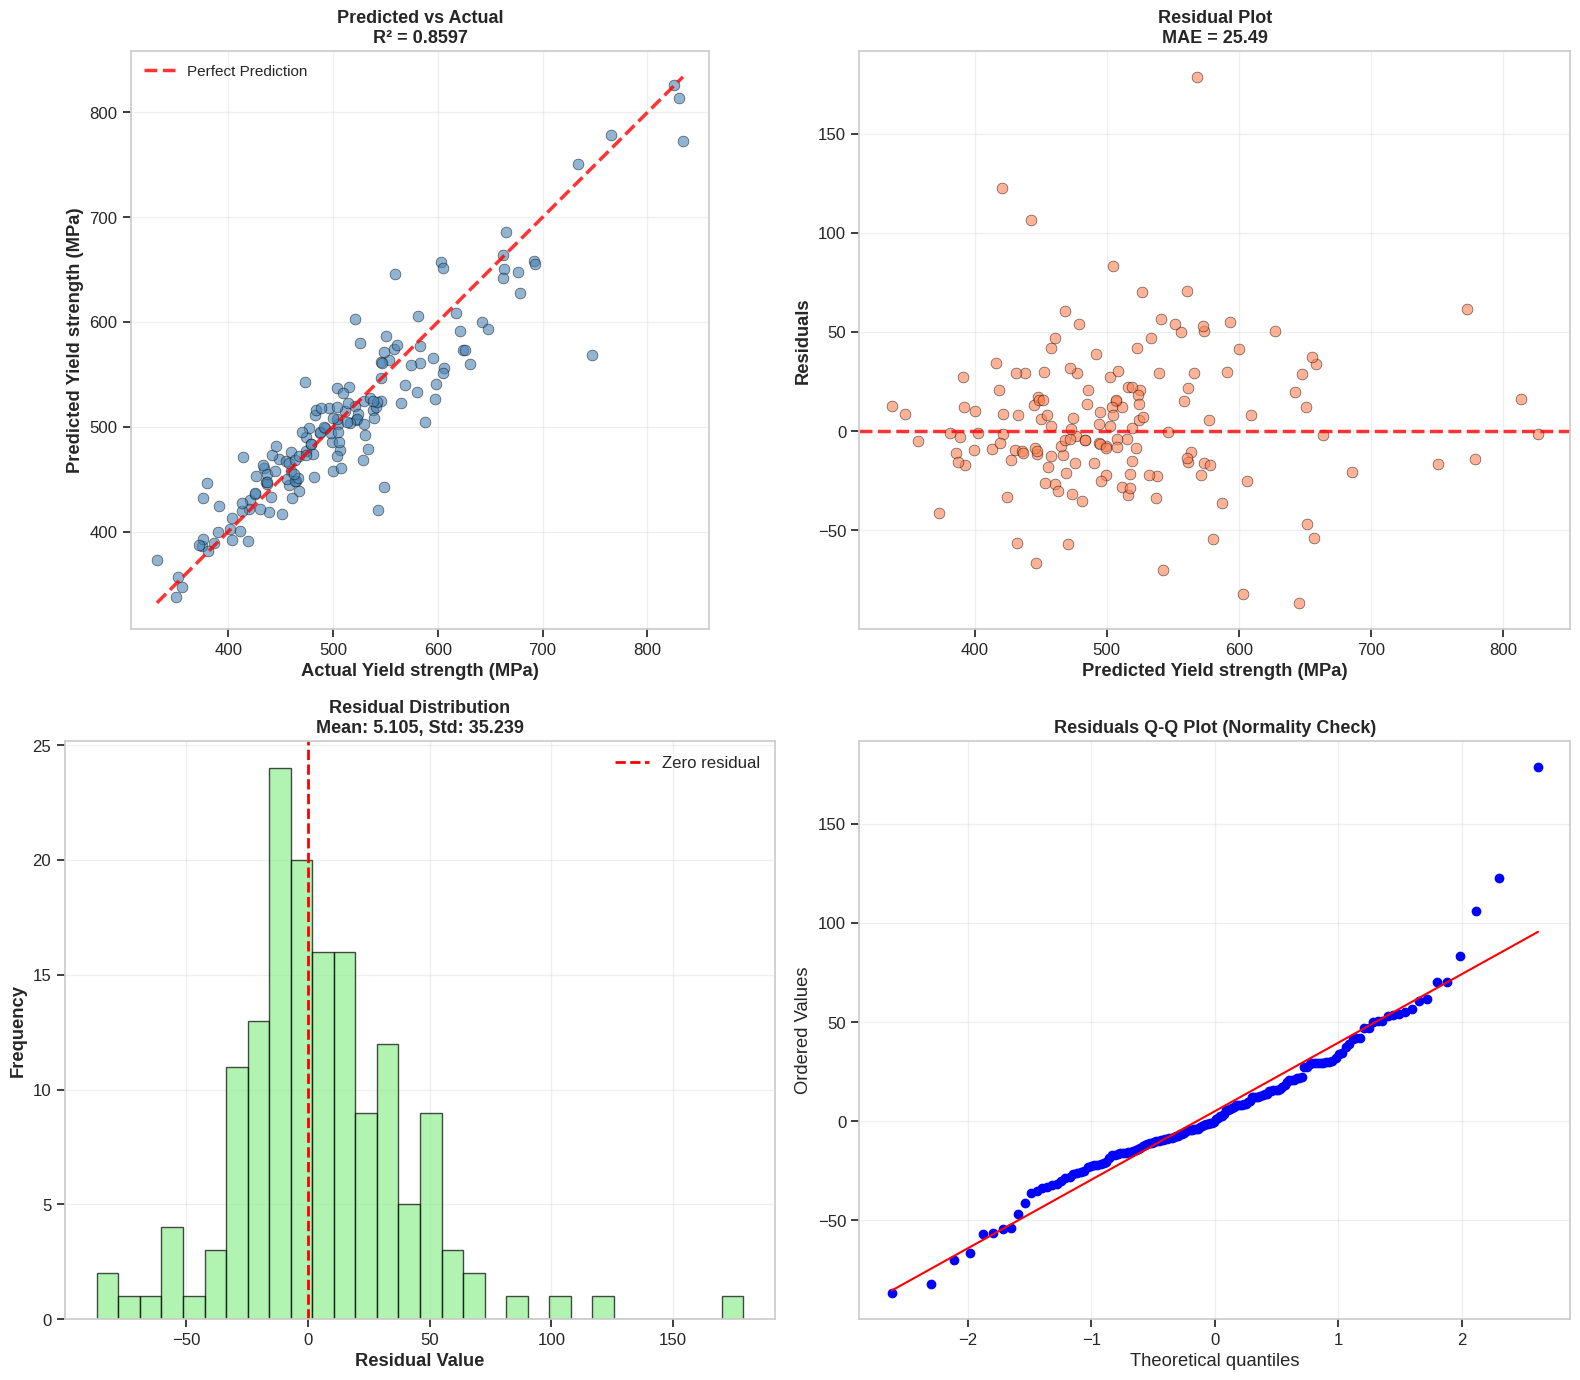


Residual Analysis:
  Mean residual:      5.1053 (should be ≈0)
  Std of residuals:   35.2395
  Min residual:       -86.5603
  Max residual:       178.6619
  Median abs error:   16.9222

  Shapiro-Wilk test:
    Statistic: 0.9426
    P-value:   0.0000
    Normal:    No (α=0.05)


In [ ]:
# Visualize predictions
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Predicted vs Actual
ax = axes[0, 0]
ax.scatter(y_test, y_pred_tuned, alpha=0.6, s=60,
          color='steelblue', edgecolors='black', linewidth=0.5)
min_val = min(y_test.min(), y_pred_tuned.min())
max_val = max(y_test.max(), y_pred_tuned.max())
ax.plot([min_val, max_val], [min_val, max_val],
       'r--', linewidth=2.5, label='Perfect Prediction', alpha=0.8)
ax.set_xlabel(f'Actual {TARGET}', fontweight='bold')
ax.set_ylabel(f'Predicted {TARGET}', fontweight='bold')
ax.set_title(f'Predicted vs Actual\nR² = {test_r2_tuned:.4f}',
            fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_aspect('equal', adjustable='box')

# Residual plot
ax = axes[0, 1]
residuals = y_test.values - y_pred_tuned
ax.scatter(y_pred_tuned, residuals, alpha=0.6, s=60,
          color='coral', edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2.5, alpha=0.8)
ax.set_xlabel(f'Predicted {TARGET}', fontweight='bold')
ax.set_ylabel('Residuals', fontweight='bold')
ax.set_title(f'Residual Plot\nMAE = {test_mae_tuned:.2f}',
            fontweight='bold', fontsize=13)
ax.grid(alpha=0.3)

# Residual distribution
ax = axes[1, 0]
ax.hist(residuals, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero residual')
ax.set_xlabel('Residual Value', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title(f'Residual Distribution\nMean: {residuals.mean():.3f}, Std: {residuals.std():.3f}',
            fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

# Q-Q plot of residuals
ax = axes[1, 1]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Residuals Q-Q Plot (Normality Check)', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Residual statistics
print("\nResidual Analysis:")
print("="*80)
print(f"  Mean residual:      {residuals.mean():.4f} (should be ≈0)")
print(f"  Std of residuals:   {residuals.std():.4f}")
print(f"  Min residual:       {residuals.min():.4f}")
print(f"  Max residual:       {residuals.max():.4f}")
print(f"  Median abs error:   {np.median(np.abs(residuals)):.4f}")

# Normality test of residuals
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\n  Shapiro-Wilk test:")
print(f"    Statistic: {shapiro_stat:.4f}")
print(f"    P-value:   {shapiro_p:.4f}")
print(f"    Normal:    {'Yes' if shapiro_p > 0.05 else 'No'} (α=0.05)")
print("="*80)

## 8. Final Model Comparison

Compare all approaches to select the best model:
1. Models with PCA features
2. XGBoost without PCA (baseline)
3. XGBoost without PCA (tuned)

COMPREHENSIVE MODEL COMPARISON

All Models Performance:
                          CV_R2_mean  CV_R2_std  CV_RMSE_mean  CV_RMSE_std   Test_R2  Test_RMSE   Test_MAE
XGBoost (Full, Tuned)       0.800012        NaN           NaN          NaN  0.859701  35.607387  25.489031
XGBoost (Full, Baseline)    0.755662   0.104797     43.319468     4.041934  0.858460  35.764540  25.879566
Gradient Boosting (PCA)     0.657702   0.037859     53.756775     3.952232       NaN        NaN        NaN
XGBoost (PCA)               0.637117   0.091649     54.972121     6.612369       NaN        NaN        NaN
SVR (PCA)                   0.609109   0.082272     57.256833     6.696612       NaN        NaN        NaN
Random Forest (PCA)         0.597705   0.042296     58.290354     4.216057       NaN        NaN        NaN
Ridge (PCA)                 0.368641   0.096908     72.767577     5.557516       NaN        NaN        NaN

BEST MODEL: XGBoost (Full, Tuned)
  Test R²:   0.8597
  Test RMSE: 35.6074
  Test MAE: 

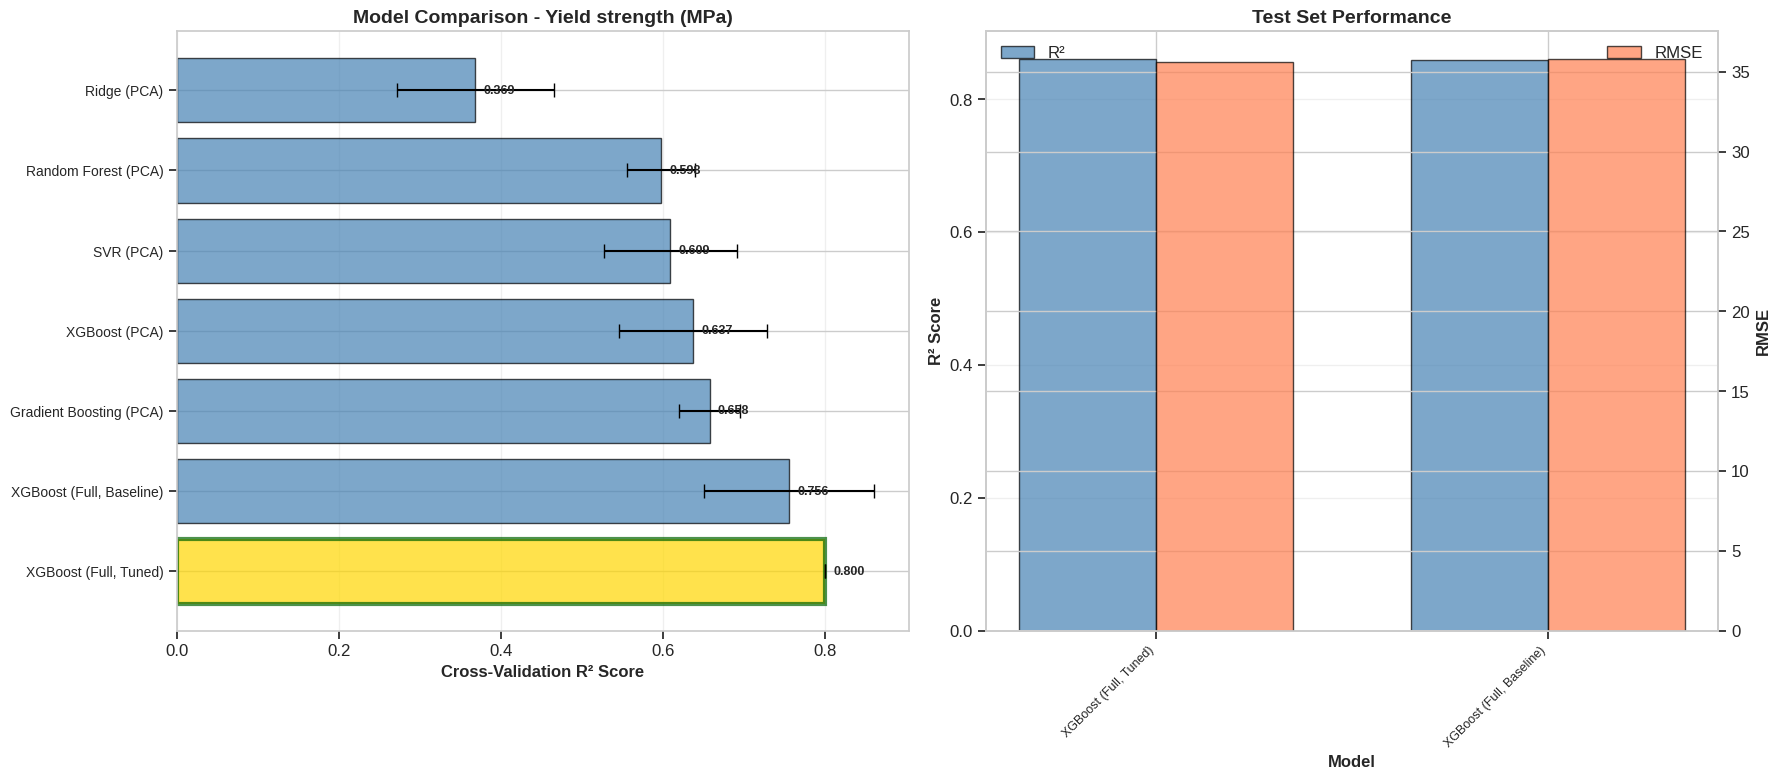

In [ ]:
# Compile all results
all_results = {}

# PCA models (CV scores only)
for model_name, results in cv_results_pca.items():
    all_results[f"{model_name} (PCA)"] = {
        'CV_R2_mean': results['r2_mean'],
        'CV_R2_std': results['r2_std'],
        'CV_RMSE_mean': results['rmse_mean'],
        'CV_RMSE_std': results['rmse_std'],
        'Test_R2': None,
        'Test_RMSE': None,
        'Test_MAE': None
    }

# XGBoost baseline
all_results['XGBoost (Full, Baseline)'] = {
    'CV_R2_mean': cv_r2_baseline.mean(),
    'CV_R2_std': cv_r2_baseline.std(),
    'CV_RMSE_mean': cv_rmse_baseline.mean(),
    'CV_RMSE_std': cv_rmse_baseline.std(),
    'Test_R2': test_r2_baseline,
    'Test_RMSE': test_rmse_baseline,
    'Test_MAE': test_mae_baseline
}

# XGBoost tuned
all_results['XGBoost (Full, Tuned)'] = {
    'CV_R2_mean': grid_search.best_score_,
    'CV_R2_std': None,
    'CV_RMSE_mean': None,
    'CV_RMSE_std': None,
    'Test_R2': test_r2_tuned,
    'Test_RMSE': test_rmse_tuned,
    'Test_MAE': test_mae_tuned
}

# Create comprehensive dataframe
results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values('CV_R2_mean', ascending=False)

print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)
print("\nAll Models Performance:")
print(results_df.to_string())

# Best model
models_with_test = results_df[results_df['Test_R2'].notna()]
best_model_idx = models_with_test['Test_R2'].idxmax()
best_model_name = best_model_idx
best_r2 = models_with_test.loc[best_model_idx, 'Test_R2']
best_rmse = models_with_test.loc[best_model_idx, 'Test_RMSE']
best_mae = models_with_test.loc[best_model_idx, 'Test_MAE']

print("\n" + "="*80)
print(f"BEST MODEL: {best_model_name}")
print("="*80)
print(f"  Test R²:   {best_r2:.4f}")
print(f"  Test RMSE: {best_rmse:.4f}")
print(f"  Test MAE:  {best_mae:.4f}")
print("="*80)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# CV R² comparison
ax = axes[0]
models_list = results_df.index.tolist()
cv_r2 = results_df['CV_R2_mean'].values
cv_r2_std = results_df['CV_R2_std'].fillna(0).values

bars = ax.barh(range(len(models_list)), cv_r2, xerr=cv_r2_std,
              color='steelblue', edgecolor='black', alpha=0.7, capsize=5)

# Highlight best model
best_idx = models_list.index(best_model_name)
bars[best_idx].set_color('gold')
bars[best_idx].set_edgecolor('darkgreen')
bars[best_idx].set_linewidth(3)

ax.set_yticks(range(len(models_list)))
ax.set_yticklabels(models_list, fontsize=10)
ax.set_xlabel('Cross-Validation R² Score', fontweight='bold', fontsize=12)
ax.set_title(f'Model Comparison - {TARGET}', fontweight='bold', fontsize=14)
ax.grid(alpha=0.3, axis='x')

for i, (r2, std) in enumerate(zip(cv_r2, cv_r2_std)):
    if not np.isnan(r2):
        ax.text(r2 + 0.01, i, f'{r2:.3f}', va='center',
               fontsize=9, fontweight='bold')

# Test scores comparison (where available)
ax = axes[1]
test_models = models_with_test.index.tolist()
test_r2 = models_with_test['Test_R2'].values
test_rmse = models_with_test['Test_RMSE'].values

x_pos = np.arange(len(test_models))
width = 0.35

ax2 = ax.twinx()
bars1 = ax.bar(x_pos - width/2, test_r2, width, label='R²',
              color='steelblue', edgecolor='black', alpha=0.7)
bars2 = ax2.bar(x_pos + width/2, test_rmse, width, label='RMSE',
               color='coral', edgecolor='black', alpha=0.7)

ax.set_xlabel('Model', fontweight='bold', fontsize=12)
ax.set_ylabel('R² Score', fontweight='bold', fontsize=12)
ax2.set_ylabel('RMSE', fontweight='bold', fontsize=12)
ax.set_title('Test Set Performance', fontweight='bold', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(test_models, rotation=45, ha='right', fontsize=9)

ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

The tuned XGBoost model delivers strong and reliable predictions for yield strength, explaining around 86% of the variance in the test data with an average error of roughly 36 MPa. Compared to the PCA-based models, which lose important variance and perform noticeably worse, the full feature approach clearly retains more relevant information for prediction. Even the baseline XGBoost already performs very well, and the tuning only brings marginal gains, showing that the model is already near its optimal configuration. Overall, these results confirm that yield strength can be effectively predicted from the given chemical composition and welding parameters, and the achieved accuracy is well within acceptable engineering limits for practical use.